**PUNTO 1**

Cualquier sonido cosenoidal tiene la forma y_hat =a * cos(bx + c) + d, nuestro error
debería ser LSE (Least Square Error) entonces nuestra función de error se puede
escribir como e(x) = (y - y_hat)^2. Ahora con la función de error tenemos que derivar
a,b,c y d=0 (Calcula el gradiente que son las derivadas parciales con respecto a a,b,c) y
aplicar el algoritmo de gradiente descendiente (Considerando que el gradiente funciona
solo con funciones convexas vamos a tomar la parte de la señal convexa, para
encontrar los parámetros).

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sounddevice as sd
from scipy.io.wavfile import write

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

Este punto se habia realizado con 10, 400, 1000 y 2000 epochs; dando como resultado en la competencia de kaggle de 0,00794; por lo cual se va incrementar a 4000 los epochs con el fin de mejorar el resultado

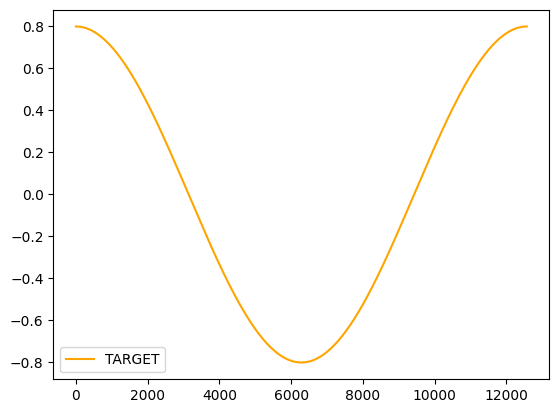

In [17]:
import numpy as np
train.plot(y='TARGET', color='orange')

def modelo_cos(w, z, u, v, datos_x):
    return w * np.cos(z * datos_x + u) + v

def calcular_gradiente(w, z, u, v, xi, yi):
    prediccion = modelo_cos(w, z, u, v, xi)
    error = yi - prediccion
    grad_w = -2 * np.mean(error * np.cos(z * xi + u))
    grad_z = 2 * np.mean(error * w * xi * np.sin(z * xi + u))
    grad_u = 2 * np.mean(error * w * np.sin(z * xi + u))
    grad_v = -2 * np.mean(error)
    return grad_w, grad_z, grad_u, grad_v

valores_x = train['x'].values
valores_y = train['TARGET'].values

def entrenar_modelo(valores_x, valores_y, tasa_aprendizaje=0.05, tamaño_lote=100, iteraciones=4000, semilla=42):
    np.random.seed(semilla)
    w = np.random.randn()
    z = np.random.randn()
    u = np.random.randn()
    v = np.random.randn()
    historial = []

    for _ in range(iteraciones):
        suma_grad_w = 0
        suma_grad_z = 0
        suma_grad_u = 0
        suma_grad_v = 0
        error_total = 0

        for _ in range(tamaño_lote):
            indice = np.random.randint(0, len(valores_x))
            xi = valores_x[indice]
            yi = valores_y[indice]
            error_total += (yi - modelo_cos(w, z, u, v, xi)) ** 2

            dw, dz, du, dv = calcular_gradiente(w, z, u, v, xi, yi)
            suma_grad_w += dw
            suma_grad_z += dz
            suma_grad_u += du
            suma_grad_v += dv

        w -= tasa_aprendizaje * suma_grad_w / tamaño_lote
        z -= tasa_aprendizaje * suma_grad_z / tamaño_lote
        u -= tasa_aprendizaje * suma_grad_u / tamaño_lote
        v -= tasa_aprendizaje * suma_grad_v / tamaño_lote

        error_promedio = error_total / tamaño_lote
        historial.append([w, z, u, v, error_promedio])

    return w, z, u, v, historial


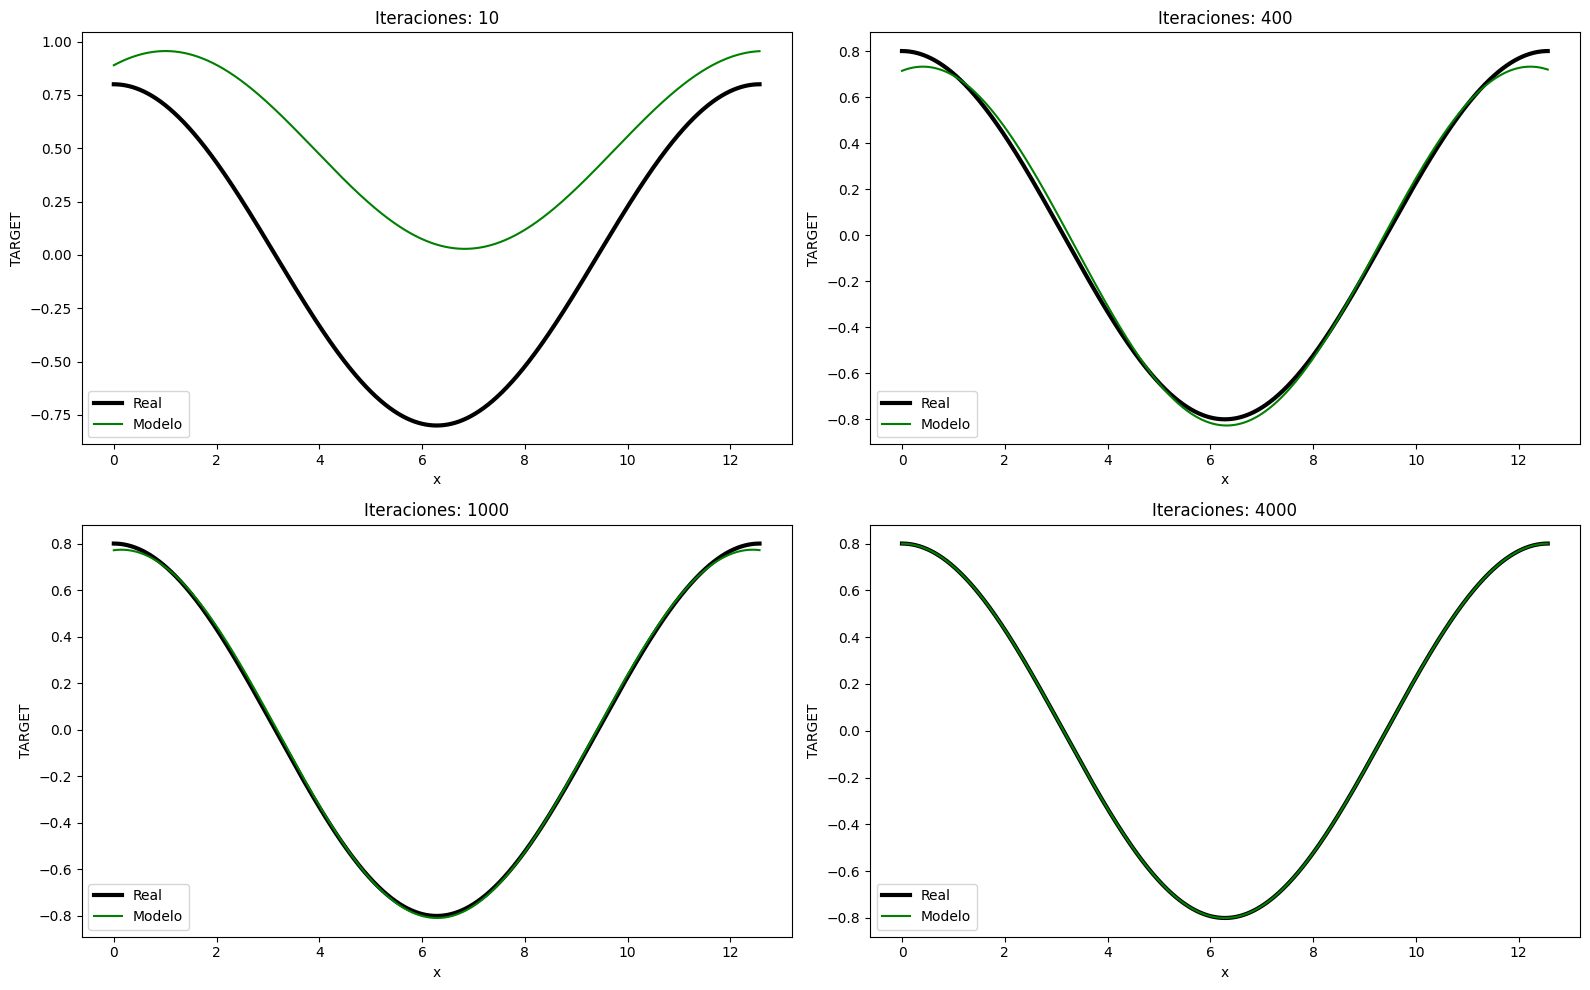

In [18]:
import matplotlib.pyplot as plt

def graficar_modelos_por_iteracion(val_x, val_y, lista_epocas=[10, 400, 1000, 4000], tasa_aprendizaje=0.05, tamaño_lote=100, semilla=42):
    figura, ejes = plt.subplots(2, 2, figsize=(16, 10))
    ejes = ejes.flatten()
    
    for idx, epocas in enumerate(lista_epocas):
        w, z, u, v, historial = entrenar_modelo(val_x, val_y,
                                                tasa_aprendizaje=tasa_aprendizaje,
                                                tamaño_lote=tamaño_lote,
                                                iteraciones=epocas,
                                                semilla=semilla)

        ejes[idx].plot(val_x, val_y, label='Real', color='black', linewidth=3)
        ejes[idx].plot(val_x, modelo_cos(w, z, u, v, val_x), label='Modelo', color='green')
        ejes[idx].set_title(f'Iteraciones: {epocas}')
        ejes[idx].set_xlabel('x')
        ejes[idx].set_ylabel('TARGET')
        ejes[idx].legend()

    plt.tight_layout()
    plt.show()

graficar_modelos_por_iteracion(valores_x, valores_y)



con los parametros aprendidos, se va a crear y dubujar una señar con un periodo de tiempo más largo

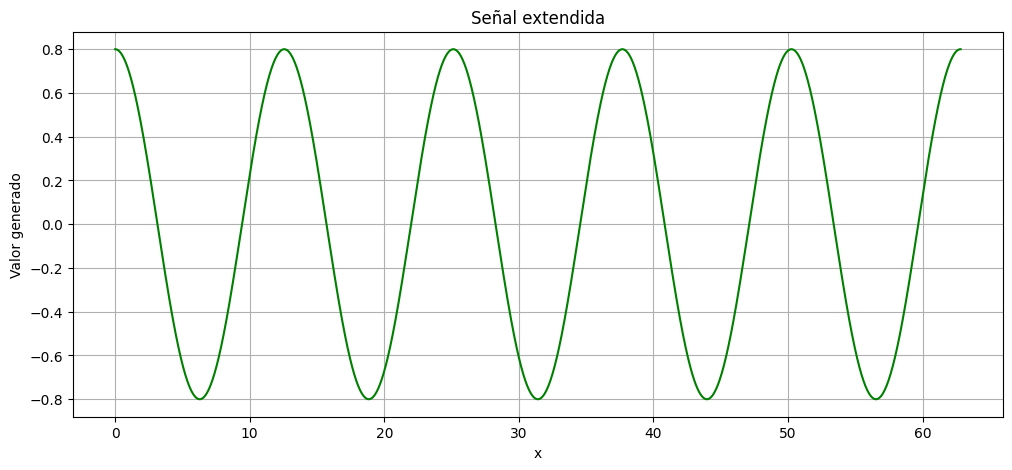

In [88]:
w, z, u, v, historial = entrenar_modelo(valores_x, valores_y)

x_inicio = np.min(valores_x)
x_extendido = np.arange(x_inicio, 20 * np.pi, 0.01).astype(np.float32)
señal_generada = [modelo_cos(w, z, u, v, xi) for xi in x_extendido]

sd.play(señal_generada)

plt.figure(figsize=(12, 5))
plt.plot(x_extendido, señal_generada, color='green')
plt.title('Señal extendida')
plt.xlabel('x')
plt.ylabel('Valor generado')
plt.grid(True)
plt.show()

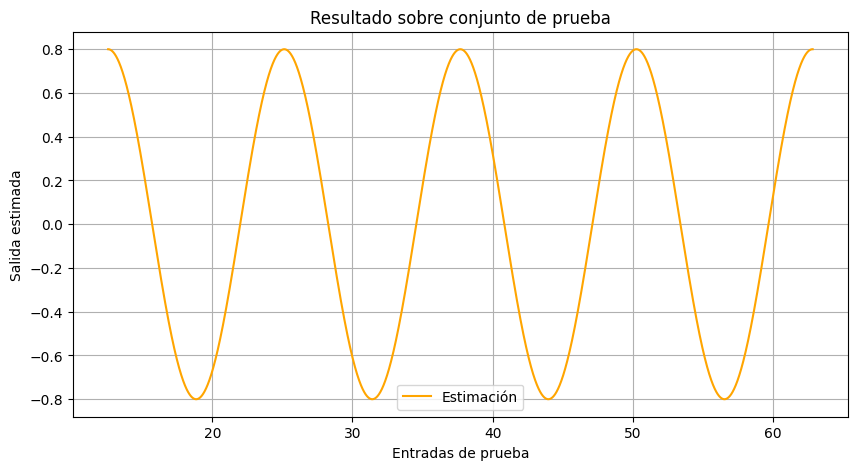

In [22]:
ids_prueba = test['example_id'].values
entradas_prueba = test['x'].values

salidas_estimadas = [modelo_cos(w, z, u, v, valor) for valor in entradas_prueba]

resultado = pd.DataFrame({
    'example_id': ids_prueba,
    'TARGET': salidas_estimadas
})

resultado.to_csv('submission.csv', index=False)

plt.figure(figsize=(10, 5))
plt.plot(entradas_prueba, salidas_estimadas, label='Estimación', color='orange')
plt.xlabel('Entradas de prueba')
plt.ylabel('Salida estimada')
plt.title('Resultado sobre conjunto de prueba')
plt.legend()
plt.grid(True)
plt.show()


Verificando con la competencia de Kaggle, el resultado siempre se logro bajar dando como score de **0,00177**

**PUNTO 2**

En este punto tuve el mismo problema que en el parcial en la importacion del ntlk para poder hacer los stopwords, por tal motivo voy a utilizar una lista de stopwords comunes para poder realizar este punto

In [79]:
import pandas as pd
import re
import unicodedata
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_csv("traintexto.csv")

def normalizar_texto(cadena):
    cadena = str(cadena).lower()
    cadena = unicodedata.normalize("NFD", cadena).encode("ascii", "ignore").decode("utf-8")
    cadena = re.sub(r'[^a-zA-Z0-9\s]', '', cadena)
    return cadena

dataset["texto_limpio"] = dataset["titulo"].apply(normalizar_texto)

stopwords = {
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las", "por", "un", "para",
    "con", "no", "una", "su", "al", "lo", "como", "más", "pero", "sus", "le", "ya", "o",
    "este", "sí", "porque", "esta", "entre", "cuando", "muy", "sin", "sobre", "también",
    "me", "hasta", "hay", "donde", "quien", "desde", "todo", "nos", "durante", "todos",
    "uno", "les", "ni", "contra", "otros", "ese", "eso", "ante", "ellos", "e", "esto",
    "mí", "antes", "algunos", "qué", "unos", "yo", "otro", "otras", "otra", "él", "tanto",
    "esa", "estos", "mucho", "quienes", "nada", "muchos", "cual", "poco", "ella", "estar",
    "estas", "algunas", "algo", "nosotros", "mi", "mis", "tú", "te", "ti", "tu", "tus",
    "ellas", "nosotras", "vosotros", "vosotras", "os", "mío", "mía", "míos", "mías", "tuyo",
    "tuya", "tuyos", "tuyas", "suyo", "suya", "suyos", "suyas", "nuestro", "nuestra",
    "nuestros", "nuestras", "vuestro", "vuestra", "vuestros", "vuestras", "esos", "esas",
    "estoy", "estás", "está", "estamos", "estáis", "están", "esté", "estés", "estemos",
    "estéis", "estén", "estaré", "estarás", "estará", "estaremos", "estaréis", "estarán",
    "estaría", "estarías", "estaríamos", "estaríais", "estarían", "estaba", "estabas",
    "estábamos", "estabais", "estaban", "estuve", "estuviste", "estuvo", "estuvimos",
    "estuvisteis", "estuvieron", "estuviera", "estuvieras", "estuviéramos", "estuvierais",
    "estuvieran", "estuviese", "estuvieses", "estuviésemos", "estuvieseis", "estuviesen",
    "estando", "estado", "estada", "estados", "estadas", "estad"
}

def remover_stopwords(texto):
    return " ".join(palabra for palabra in texto.split() if palabra not in stopwords)

dataset["texto_filtrado"] = dataset["texto_limpio"].apply(remover_stopwords)

print(dataset[["titulo", "texto_limpio", "texto_filtrado"]].head())


                                              titulo  \
0  "De nada sirven los triunfos si la paz no los ...   
1  "Hay mejores formas para uno mostrar su forma ...   
2                #LosNacionalesXSeñal - Bahía Cupica   
3  #LosNacionalesXSeñal - Estudiantes Utech balon...   
4  #LosNacionalesXSeñal - Las pruebas de triatlón...   

                                        texto_limpio  \
0  de nada sirven los triunfos si la paz no los c...   
1  hay mejores formas para uno mostrar su forma d...   
2                  losnacionalesxsenal  bahia cupica   
3   losnacionalesxsenal  estudiantes utech balonmano   
4  losnacionalesxsenal  las pruebas de triatlon l...   

                                      texto_filtrado  
0           sirven triunfos si paz corona lapazhabla  
1          mejores formas mostrar forma pensar sofia  
2                   losnacionalesxsenal bahia cupica  
3    losnacionalesxsenal estudiantes utech balonmano  
4  losnacionalesxsenal pruebas triatlon llenaron ..

In [80]:
codificador = LabelEncoder()
etiquetas_codificadas = codificador.fit_transform(dataset["categoria"])
mapeo_etiquetas = dict(zip(codificador.classes_, codificador.transform(codificador.classes_)))
print(mapeo_etiquetas)

lista_textos = dataset["texto_filtrado"].tolist()
tfidf_vect = TfidfVectorizer()
matriz_tfidf = tfidf_vect.fit_transform(lista_textos)
print("Dimensiones de la matriz TF-IDF:", matriz_tfidf.shape)



{'Deportes': 0, 'Educación': 1, 'Entretenimiento': 2, 'Gente y Blogs': 3, 'Otros': 4, 'Película y Animación': 5}
Dimensiones de la matriz TF-IDF: (800, 1730)


**Entrenamiento de Regresiòn Logistica**

Metricas Reg Log
                      precision    recall  f1-score   support

            Deportes       0.89      0.89      0.89        38
           Educación       0.75      0.25      0.38        24
     Entretenimiento       0.58      0.85      0.69        48
       Gente y Blogs       1.00      0.12      0.22         8
               Otros       1.00      0.20      0.33        10
Película y Animación       0.47      0.59      0.53        32

            accuracy                           0.64       160
           macro avg       0.78      0.49      0.51       160
        weighted avg       0.71      0.64      0.61       160



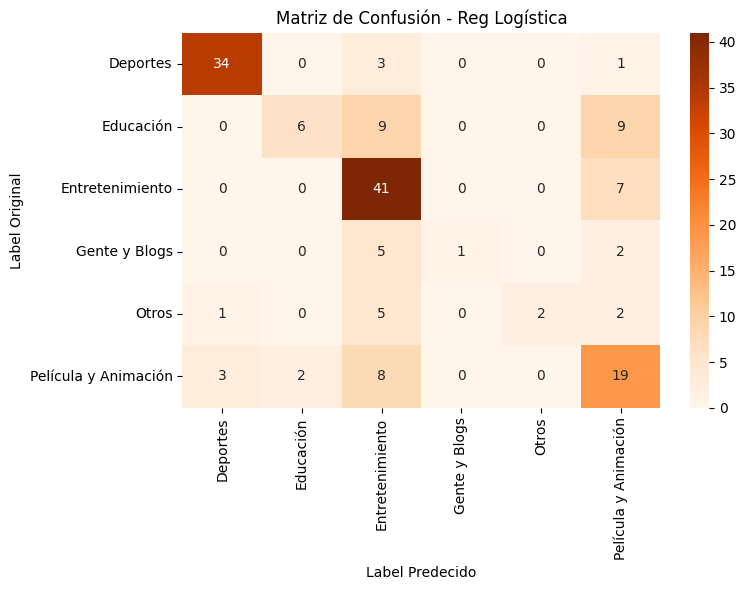

In [86]:
X_entreno, X_validacion, y_entreno, y_validacion = train_test_split(
    matriz_tfidf, etiquetas_codificadas, test_size=0.2, random_state=42
)

modelo_logistico = LogisticRegression(max_iter=1000)
modelo_logistico.fit(X_entreno, y_entreno)

predicciones = modelo_logistico.predict(X_validacion)

print("Metricas Reg Log")
print(classification_report(y_validacion, predicciones, target_names=codificador.classes_))

matriz_confusion = confusion_matrix(y_validacion, predicciones)
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_confusion,
    annot=True,
    fmt="d",
    xticklabels=codificador.classes_,
    yticklabels=codificador.classes_,
    cmap="Oranges"
)
plt.xlabel("Label Predecido")
plt.ylabel("Label Original")
plt.title("Matriz de Confusión - Reg Logística")
plt.tight_layout()
plt.show()


**Entrenamiento Random Forest**

Metricas con el Modelo:(Random Forest):
                      precision    recall  f1-score   support

            Deportes       0.88      0.74      0.80        38
           Educación       0.58      0.29      0.39        24
     Entretenimiento       0.67      0.79      0.72        48
       Gente y Blogs       0.67      0.25      0.36         8
               Otros       0.71      0.50      0.59        10
Película y Animación       0.49      0.75      0.59        32

            accuracy                           0.65       160
           macro avg       0.67      0.55      0.58       160
        weighted avg       0.67      0.65      0.64       160



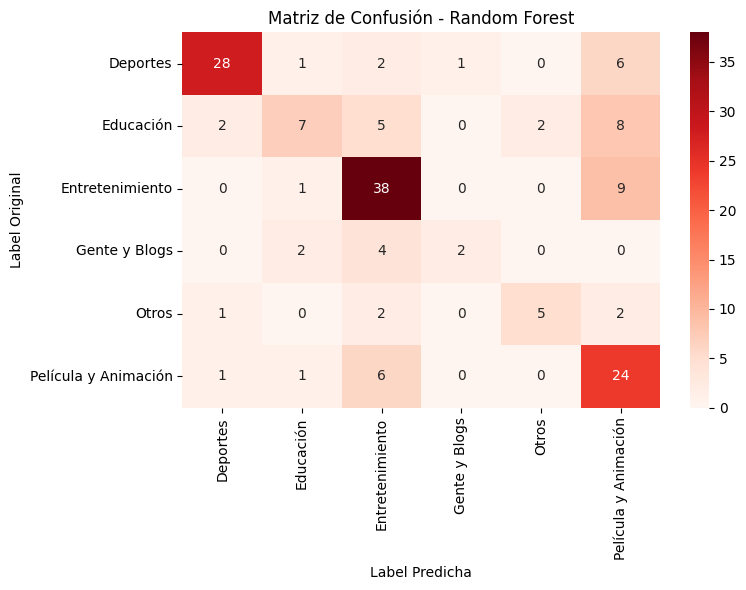

In [82]:
bosque_aleatorio = RandomForestClassifier(n_estimators=100, random_state=42)
bosque_aleatorio.fit(X_entreno, y_entreno)

predicciones_rf = bosque_aleatorio.predict(X_validacion)

print("Metricas con el Modelo:(Random Forest):")
print(classification_report(y_validacion, predicciones_rf, target_names=codificador.classes_))

matriz_confusion_rf = confusion_matrix(y_validacion, predicciones_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_confusion_rf,
    annot=True,
    fmt='d',
    xticklabels=codificador.classes_,
    yticklabels=codificador.classes_,
    cmap="Reds"
)
plt.xlabel("Label Predicha")
plt.ylabel("Label Original")
plt.title("Matriz de Confusión - Random Forest")
plt.tight_layout()
plt.show()


In [83]:
texto_filtrado = dataset["texto_filtrado"].tolist()

tokenizador = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizador.fit_on_texts(texto_filtrado)

secuencias_texto = tokenizador.texts_to_sequences(texto_filtrado)

longitud_maxima = max(len(sec) for sec in secuencias_texto)

X_padded = pad_sequences(secuencias_texto, maxlen=longitud_maxima, padding='post')

codificador_etiquetas = LabelEncoder()
y_codificado = codificador_etiquetas.fit_transform(dataset["categoria"])
cantidad_clases = len(codificador_etiquetas.classes_)

X_entrenamiento, X_validacion, y_entrenamiento, y_validacion = train_test_split(
    X_padded, y_codificado, test_size=0.2, random_state=42
)

y_train_onehot = to_categorical(y_entrenamiento, num_classes=cantidad_clases)
y_val_onehot = to_categorical(y_validacion, num_classes=cantidad_clases)


In [84]:
red_neuronal = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=max_length),
    LSTM(units=64),
    Dense(units=num_classes, activation='softmax')
])

# Compilar el modelo con función de pérdida y optimizador
red_neuronal.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Entrenar la red neuronal con datos de entrenamiento y validación
historial = red_neuronal.fit(
    X_train, 
    y_train_cat, 
    validation_data=(X_val, y_val_cat), 
    epochs=10, 
    batch_size=32
)
pérdida, precisión = red_neuronal.evaluate(X_val, y_val_cat)
print(f"Precisión del modelo LSTM: {precisión:.2f}")

Epoch 1/10


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2546 - loss: 1.7643 - val_accuracy: 0.3000 - val_loss: 1.6442
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3132 - loss: 1.6518 - val_accuracy: 0.3000 - val_loss: 1.6039
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3829 - loss: 1.5724 - val_accuracy: 0.4563 - val_loss: 1.4018
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5452 - loss: 1.1555 - val_accuracy: 0.5188 - val_loss: 1.3083
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6595 - loss: 0.9310 - val_accuracy: 0.5437 - val_loss: 1.3080
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6999 - loss: 0.7306 - val_accuracy: 0.5125 - val_loss: 1.5212
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7773 - loss: 0.6081 - val_accuracy: 0.5063 - val_loss: 1.4230
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8260 - loss: 0.4531 - val_accuracy: 0.4875 - val_loss: 1.5965
Epo

Entre los tres modelos evaluados para la clasificación de texto, **Random Forest** fue el que mostró mejor desempeño general. Aunque la Regresión Logística tuvo una precisión similar (64%), su capacidad para clasificar correctamente categorías menos frecuentes fue menor. El modelo LSTM, a pesar de tener alta precisión en entrenamiento, sufrió de sobreajuste y obtuvo menor precisión en validación (51%) y prueba (47%).

**Por tanto, Random Forest es el modelo más equilibrado y recomendable para esta tarea, destacando en precisión y f1-score entre todas las clases.**

In [85]:
datos_prueba = pd.read_csv("testtexto.csv")

datos_prueba["texto_limpio"] = datos_prueba["titulo"].apply(limpiar_texto)

# Filtrado de stopwords
datos_prueba["texto_filtrado"] = datos_prueba["texto_limpio"].apply(
    lambda texto: " ".join(palabra for palabra in texto.split() if palabra not in stopwords_esp)
)

# Convertir textos a secuencias de tokens
secuencias_prueba = tokenizer.texts_to_sequences(datos_prueba["texto_filtrado"])

# Padding para igualar longitud
X_prueba = pad_sequences(secuencias_prueba, maxlen=max_length, padding='post')

# Predicciones probabilísticas con el modelo entrenado
predicciones_prob = red_neuronal.predict(X_prueba)

# Obtener clase con mayor probabilidad
clases_predichas = predicciones_prob.argmax(axis=1)

# Decodificar etiquetas a sus nombres originales
categorias_predichas = le.inverse_transform(clases_predichas)

# Crear DataFrame con resultados
resultados = pd.DataFrame({
    "ID": datos_prueba["index"],           
    "categoria": categorias_predichas
})

# Guardar resultados en archivo CSV
resultados.to_csv("submission_texto.csv", index=False, encoding='utf-8')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
